In [ ]:
from project_utils import *


In [1]:
import os
import pandas as pd
import numpy as np
import pickle
import tqdm
from joblib import Parallel, delayed
from numba import njit
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# R setup
os.environ['R_HOME'] = 'C:\\Program Files\\R\\R-4.4.1'
os.environ["PATH"] += os.pathsep + r"C:\Program Files\R\R-4.4.1\bin\x64"
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
pandas2ri.activate()


In [3]:
def calculate_single_task(test_row, train_feats_for_word, tau=2.0):
    test_word = test_row['Keyword']
    test_spk = test_row['TestTalker']
    test_feat = test_row['feature']
    
    if test_word not in train_feats_for_word:
        return {'similarity': np.nan, 'raw_distance': np.nan}
        
    train_candidates = train_feats_for_word[test_word]
    if len(train_candidates) == 0:
        return {'similarity': np.nan, 'raw_distance': np.nan}
        
    distances = []
    for train_feat in train_candidates:
        d = dtw_raw_distance(test_feat, train_feat, tau)
        distances.append(d)
        
    return {'raw_distance': np.mean(distances)}

def process_layer_distances(layer_name, layer_dict, df_test):
    df_layer = df_test.copy()
    features = []
    
    # Extract features for test rows
    for idx, row in df_layer.iterrows():
        spk = row['TestTalker']
        word = row['Keyword']
        if spk in layer_dict and word in layer_dict[spk]:
            features.append(layer_dict[spk][word])
        else:
            features.append(None)
            
    df_layer['feature'] = features
    df_layer = df_layer.dropna(subset=['feature'])
    
    # Prepare train candidates per fold
    # Test conditions: 
    # Exposure = df_layer['ExposureCondition'] (match with talkers)
    # Actually, in Nygaard, df_test already has 'fold'
    folds = sorted(df_layer['fold'].unique())
    num_folds = len(folds)
    
    all_results = []
    for i, test_fold in enumerate(folds):
        train_fold = folds[(i + 2) % num_folds]
        
        df_train_fold = df_layer[df_layer['fold'] == train_fold]
        df_test_fold = df_layer[df_layer['fold'] == test_fold].copy()
        
        train_feats_for_word = {}
        for _, row in df_train_fold.iterrows():
            w = row['Keyword']
            if w not in train_feats_for_word:
                train_feats_for_word[w] = []
            train_feats_for_word[w].append(row['feature'])
            
        # Compute distances for this test fold
        fold_res = Parallel(n_jobs=-1)(
            delayed(calculate_single_task)(row, train_feats_for_word) 
            for _, row in df_test_fold.iterrows()
        )
        
        df_test_fold['raw_distance'] = [r['raw_distance'] for r in fold_res]
        all_results.append(df_test_fold)
        
    return pd.concat(all_results, ignore_index=True)


In [7]:
df_test

,TrainingAccent,TestAccent,Subject,initials,SessionDate,Sex,Trial,Phase,BlockList,FileName,Accent,Speaker,EasyHard,Word,accuracy,correct,response,rt
0,Korean,Korean,1,mv,2009-02-27,male,6.0,Learning,WordList3a,km6ew30 cause.wav,k,m6,ew,30 cause.wav,1,cause,cause,2958
1,Korean,Korean,1,mv,2009-02-27,male,2.0,Learning,WordList1b,km6hw07 cheer.wav,k,m6,hw,07 cheer.wav,0,cheer,chair,4368
2,Korean,Korean,1,mv,2009-02-27,male,16.0,Learning,WordList1b,km2ew02 down.wav,k,m2,ew,02 down.wav,1,down,down,1677
3,Korean,Korean,1,mv,2009-02-27,male,20.0,Learning,WordList3a,kf4hw11 dune.wav,k,f4,hw,11 dune.wav,0,dune,toon,4526
4,Korean,Korean,1,mv,2009-02-27,male,23.0,Learning,WordList1a,kf6hw16 lad.wav,k,f6,hw,16 lad.wav,0,lad,lead,2445
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24955,NaN,Spanish,67,KC,NaT,female,NaN,Test,TestBlock1,sf6ew58 shop.wav,s,f6,ew,58 shop.wav,1,shop,shop,963
24956,NaN,Spanish,67,KC,NaT,female,NaN,Test,TestBlock1,sm2ew63 soil.wav,s,m2,ew,63 soil.wav,1,soil,soil,1101
24957,NaN,Spanish,67,KC,NaT,female,NaN,Test,TestBlock1,sf4ew54 thick.wav,s,f4,ew,54 thick.wav,0,thick,take,1224
24958,NaN,Spanish,67,KC,NaT,female,NaN,Test,TestBlock1,sf2ew51 dog.wav,s,f2,ew,51 dog.wav,0,dog,the,745


In [8]:

# 1. Load behavioral data and folds
print("Loading behavioral data...")
df_test = pd.read_excel(r'../data/raw_data/alexander_nygaard19/AN19-exposure-test-behavioral-data.xlsx')
df_test["Speaker_full"]=df_test["Accent"]+df_test["Speaker"]
df_test["TrainingAccent"]=df_test["TrainingAccent"].fillna("English")
df_test_test=df_test[df_test["Phase"]=="Test"]
# Need to make sure df_test has 'TestTalker', 'Keyword', 'fold', 'SubjectID', 'NumCorrect'
# The saved csv should have 'Speaker_full', 'correct', 'accuracy', 'Subject', 'fold'
print(df_test.head(2))

# 2. Load Old Pickle
print("Loading old pickle...")
pkl_path = r'C:\Users\Alex\Desktop\Pycharm\cross-talker-ASR\cross-validation\hubert_Nygaard_combined_CNN_TR_dict.pkl'
with open(pkl_path, 'rb') as f:
    old_data = pickle.load(f)

# The keys in old_data are cnn_2, cnn_3 ... tr_2, tr_4
layer_keys = ['cnn_2', 'cnn_3', 'cnn_4', 'cnn_5', 'cnn_6', 'tr_2', 'tr_4', 'tr_6', 'tr_8', 'tr_10', 'tr_12', 'tr_14', 'tr_16', 'tr_18', 'tr_20', 'tr_22', 'tr_24']

all_glmm_results = []

for layer in layer_keys:
    print(f"Processing {layer}...")
    layer_dict = old_data[layer]
    
    # Calculate distances
    df_layer_dist = process_layer_distances(layer, layer_dict, df_test)
    
    # Run GLMM
    res = process_layer_nygaard_l2(layer, df_layer_dist)
    if res is not None and not res.empty:
        all_glmm_results.append(res)
        print(f"Mean z_test for {layer}:", res['z_test'].mean())

final_df = pd.concat(all_glmm_results, ignore_index=True)
final_df.to_csv('results/nygaard19_glmm_results_old_tsne.csv', index=False)
print("results/Finished saving to nygaard19_glmm_results_old_tsne.csv")


Loading behavioral data...
  TrainingAccent TestAccent  Subject initials SessionDate   Sex  Trial  \
0         Korean     Korean        1       mv  2009-02-27  male    6.0   
1         Korean     Korean        1       mv  2009-02-27  male    2.0   

      Phase   BlockList           FileName Accent Speaker EasyHard  \
0  Learning  WordList3a  km6ew30 cause.wav      k      m6       ew   
1  Learning  WordList1b  km6hw07 cheer.wav      k      m6       hw   

           Word  accuracy correct response    rt Speaker_full  
0  30 cause.wav         1   cause    cause  2958          km6  
1  07 cheer.wav         0   cheer    chair  4368          km6  
Loading old pickle...
Processing cnn_2...


KeyError: 'TestTalker'

In [10]:
# 1. Load behavioral data and folds
print("Loading behavioral data...")
df_full = pd.read_excel(r'../data/raw_data/alexander_nygaard19/AN19-exposure-test-behavioral-data.xlsx')

# --- 复制你过去的 Fold 划分逻辑 ---
df_test = df_full[df_full["Phase"]=="Test"].copy().reset_index(drop=True)

df_test_TrainingFile = []
df_test_TestFile = []
for index, row in df_test.iterrows():
    current_participant = row["Subject"]
    df_test_TrainingFile.append("_".join(sorted(list(df_full[(df_full["Subject"]==current_participant) & (df_full["Phase"]=="Learning")]["FileName"].dropna().astype(str)))))
    df_test_TestFile.append("_".join(sorted(list(df_full[(df_full["Subject"]==current_participant) & (df_full["Phase"]=="Test")]["FileName"].dropna().astype(str)))))
    
df_test["TrainingFile"] = df_test_TrainingFile
df_test["TestFile"] = df_test_TestFile
df_test["TrainingFile"] = df_test["TrainingFile"].apply(lambda x: "English" if x=="" else x)
df_test["TrainingTestFile"] = df_test["TrainingFile"] + df_test["TestFile"]

from sklearn.model_selection import StratifiedKFold, KFold
participants_df = df_test[['Subject', 'TrainingTestFile']].drop_duplicates().reset_index(drop=True)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
participants_df['fold'] = -1
try:
    split_generator = skf.split(participants_df, participants_df['TrainingTestFile'])
    for fold_idx, (train_index, test_index) in enumerate(split_generator):
        participants_df.loc[test_index, 'fold'] = fold_idx + 1
except ValueError as e:
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    for fold_idx, (train_index, test_index) in enumerate(kf.split(participants_df)):
        participants_df.loc[test_index, 'fold'] = fold_idx + 1
df_test = df_test.merge(participants_df[['Subject', 'fold']], on='Subject', how='left')

# --- 加上你缺少的重命名逻辑和特征名拼接 ---
df_test["Speaker_full"] = df_test["Accent"].astype(str) + df_test["Speaker"].astype(str)

rename_map = {
    'correct': 'Keyword',
    'Speaker_full': 'TestTalker',
    'accuracy': 'NumCorrect',
    'Subject': 'SubjectID'
}
df_test.rename(columns=rename_map, inplace=True)

# 确保提取出来了，打印出来看看有没有 fold 和 TestTalker
print(df_test[['SubjectID', 'TestTalker', 'Keyword', 'fold', 'NumCorrect']].head(2))


# 2. Load Old Pickle
print("Loading old pickle...")
import pickle
pkl_path = r'C:\Users\Alex\Desktop\Pycharm\cross-talker-ASR\cross-validation\hubert_Nygaard_combined_CNN_TR_dict.pkl'
with open(pkl_path, 'rb') as f:
    old_data = pickle.load(f)

# The keys in old_data are cnn_2, cnn_3 ... tr_2, tr_4
layer_keys = ['cnn_2', 'cnn_3', 'cnn_4', 'cnn_5', 'cnn_6', 'tr_2', 'tr_4', 'tr_6', 'tr_8', 'tr_10', 'tr_12', 'tr_14', 'tr_16', 'tr_18', 'tr_20', 'tr_22', 'tr_24']

all_glmm_results = []
from joblib import Parallel, delayed
def calculate_single_layer_pipeline(layer, layer_dict, df_test):
    print(f"Processing {layer} in background...")
    # 1. 计算当前层的 DTW 距离 (内部其实也有多线程，可以设置 n_jobs=1 避免嵌套争抢，或者不管它)
    df_layer_dist = process_layer_distances(layer, layer_dict, df_test)
    # 2. 跑 Optuna 优化和 GLMM 拟合
    res = process_layer_nygaard_l2(layer, df_layer_dist)
    if res is not None and not res.empty:
        print(f"Finished {layer} -> Mean z_test: {res['z_test'].mean()}")
    return res

print("Starting parallel GLMM calculations for all layers...")
# 使用 joblib 同时处理所有层，n_jobs=-1 也就是调用你 CPU 的所有核心
all_glmm_results = Parallel(n_jobs=-1, verbose=10)(
    delayed(calculate_single_layer_pipeline)(layer, old_data[layer], df_test)
    for layer in layer_keys
)

# 过滤掉空的返回结果并合并
all_glmm_results = [r for r in all_glmm_results if r is not None and not r.empty]

import pandas as pd
final_df = pd.concat(all_glmm_results, ignore_index=True)
final_df.to_csv('results/nygaard19_glmm_results_old_tsne.csv', index=False)
print("results/Finished saving to nygaard19_glmm_results_old_tsne.csv")

Loading behavioral data...
   SubjectID TestTalker Keyword  fold  NumCorrect
0          1        km8    dirt     3           1
1          1        kf5    mace     3           1
Loading old pickle...
Starting parallel GLMM calculations for all layers...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done   2 out of  17 | elapsed:  3.5min remaining: 26.0min
[Parallel(n_jobs=-1)]: Done   4 out of  17 | elapsed:  3.7min remaining: 12.0min
[Parallel(n_jobs=-1)]: Done   6 out of  17 | elapsed:  3.8min remaining:  7.0min
[Parallel(n_jobs=-1)]: Done   8 out of  17 | elapsed:  3.9min remaining:  4.4min
[Parallel(n_jobs=-1)]: Done  10 out of  17 | elapsed:  4.0min remaining:  2.8min
[Parallel(n_jobs=-1)]: Done  12 out of  17 | elapsed:  4.5min remaining:  1.9min
[Parallel(n_jobs=-1)]: Done  14 out of  17 | elapsed:  6.0min remaining:  1.3min


Finished saving to nygaard19_glmm_results_old_tsne.csv


[Parallel(n_jobs=-1)]: Done  17 out of  17 | elapsed: 112.1min finished


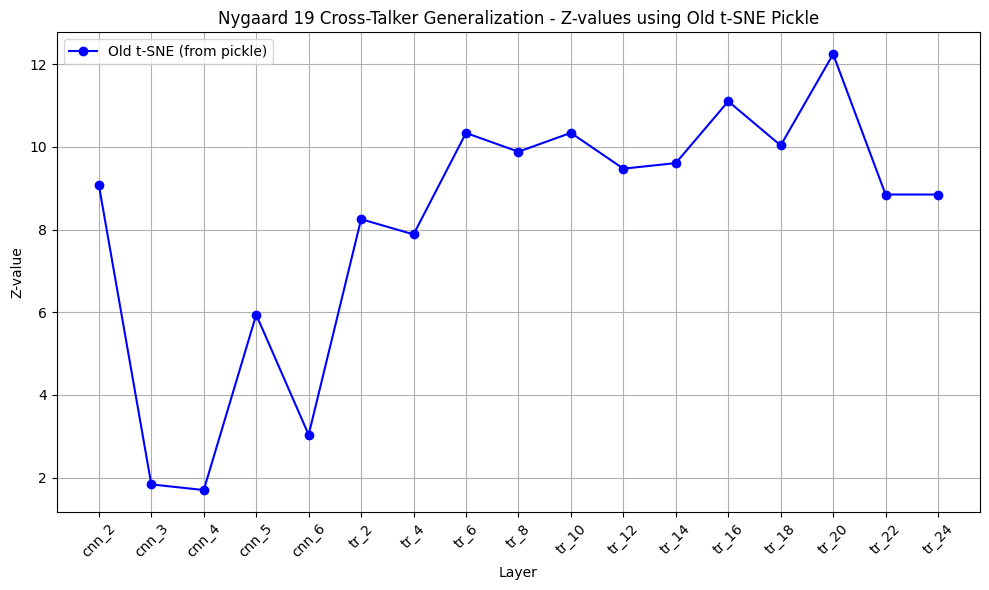

In [11]:

df_res = pd.read_csv('results/nygaard19_glmm_results_old_tsne.csv')
grouped = df_res.groupby('layer')['z_test'].mean().reindex(layer_keys)

plt.figure(figsize=(10, 6))
plt.plot(grouped.index, grouped.values, marker='o', color='blue', label='Old t-SNE (from pickle)')
plt.title("Nygaard 19 Cross-Talker Generalization - Z-values using Old t-SNE Pickle")
plt.ylabel("Z-value")
plt.xlabel("Layer")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("plots/old_tsne_plot.png")
plt.show()
